In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix
)


PALETTE = {
    "train"  : "#4C72B0",
    "test"   : "#DD8452",
    "accent" : "#55A868",
    "bg"     : "#F8F9FA",
}

print("All libraries imported successfully.")

All libraries imported successfully.


In [40]:
df = pd.read_csv("crime_dataset_india.csv")
print(f"\n Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()


 Loaded: 40,160 rows × 14 columns
Columns: ['Report Number', 'Date Reported', 'Date of Occurrence', 'Time of Occurrence', 'City', 'Crime Code', 'Crime Description', 'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain', 'Police Deployed', 'Case Closed', 'Date Case Closed']


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


In [41]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:")
df.describe(include="all")

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       40160 non-null  int64 
 1   Date Reported       40160 non-null  object
 2   Date of Occurrence  40160 non-null  object
 3   Time of Occurrence  40160 non-null  object
 4   City                40160 non-null  object
 5   Crime Code          40160 non-null  int64 
 6   Crime Description   40160 non-null  object
 7   Victim Age          40160 non-null  int64 
 8   Victim Gender       40160 non-null  object
 9   Weapon Used         34370 non-null  object
 10  Crime Domain        40160 non-null  object
 11  Police Deployed     40160 non-null  int64 
 12  Case Closed         40160 non-null  object
 13  Date Case Closed    20062 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.3+ MB
None

Missing values:
 Report Number             0
Date

,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
count,40160.000000,40160,40160,40160,40160,40160.000000,40160,40160.00000,40160,34370,40160,40160.000000,40160,20062
unique,NaN,25546,40160,39886,29,NaN,21,NaN,3,6,4,NaN,2,16011
top,NaN,03-01-2022 20:00,07-30-2024 15:00,14-10-2022 06:54,Delhi,NaN,BURGLARY,NaN,F,Knife,Other Crime,NaN,No,04-05-2024 18:00
freq,NaN,7,1,3,5400,NaN,1980,NaN,22423,5835,22948,NaN,20098,6
mean,20080.500000,NaN,NaN,NaN,NaN,349.360259,NaN,44.49126,NaN,NaN,NaN,10.006250,NaN,NaN
std,11593.337742,NaN,NaN,NaN,NaN,144.169205,NaN,20.22555,NaN,NaN,NaN,5.467951,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,100.000000,NaN,10.00000,NaN,NaN,NaN,1.000000,NaN,NaN
25%,10040.750000,NaN,NaN,NaN,NaN,225.000000,NaN,27.00000,NaN,NaN,NaN,5.000000,NaN,NaN
50%,20080.500000,NaN,NaN,NaN,NaN,349.000000,NaN,44.00000,NaN,NaN,NaN,10.000000,NaN,NaN
75%,30120.250000,NaN,NaN,NaN,NaN,474.000000,NaN,62.00000,NaN,NaN,NaN,15.000000,NaN,NaN


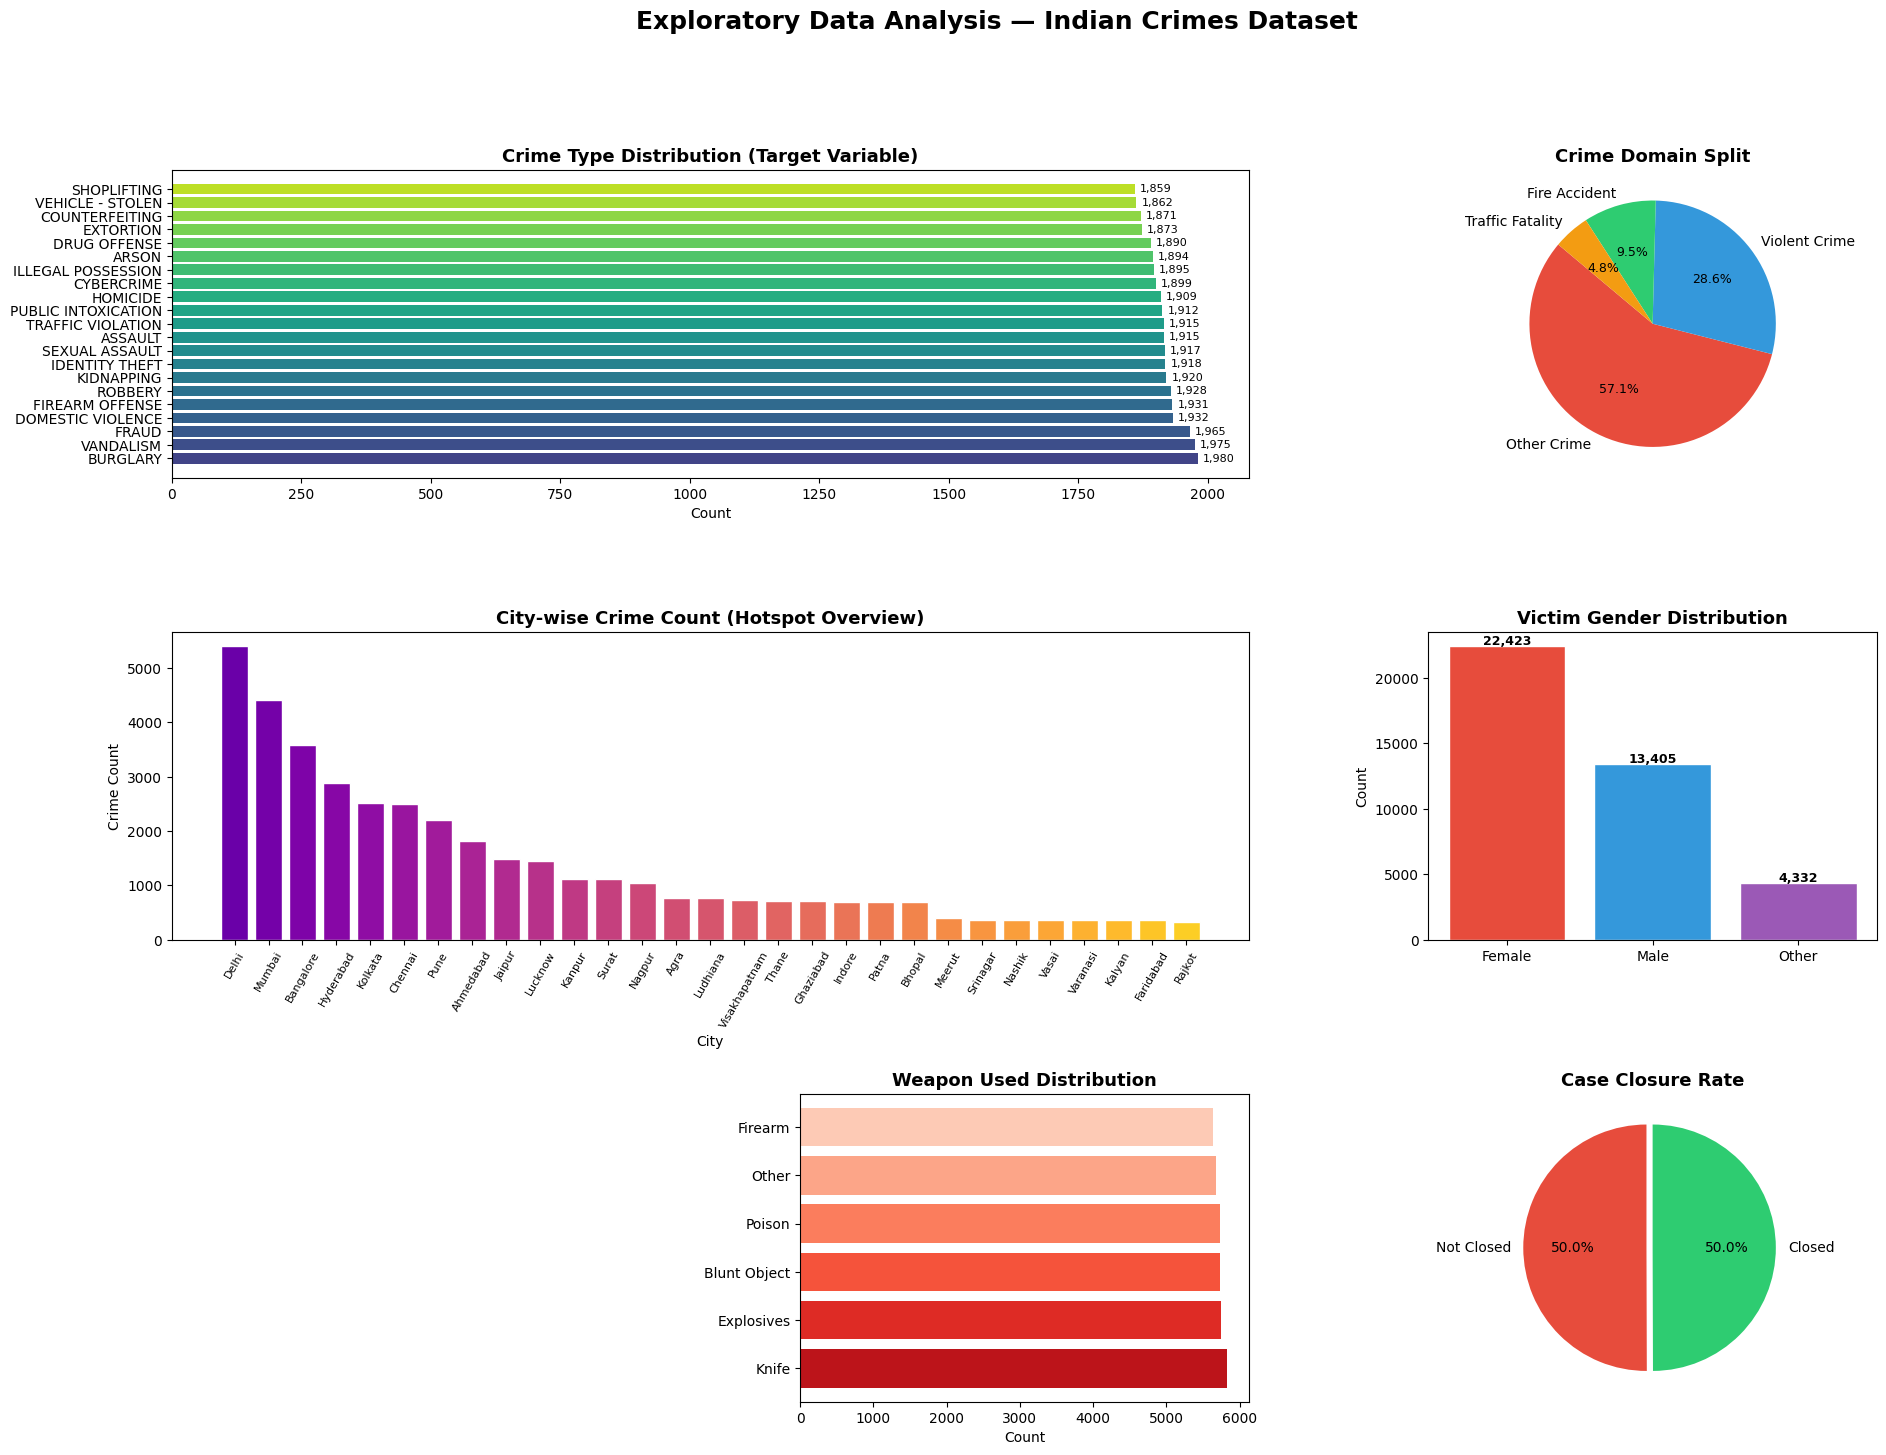

EDA saved → eda_overview.png


In [42]:
fig = plt.figure(figsize=(22, 16))
fig.suptitle("Exploratory Data Analysis — Indian Crimes Dataset",
             fontsize=18, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# Plot 1: Crime Description (Target) distribution
ax1 = fig.add_subplot(gs[0, :2])
crime_counts = df["Crime Description"].value_counts()
bars = ax1.barh(crime_counts.index, crime_counts.values,
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(crime_counts))))
ax1.set_title("Crime Type Distribution (Target Variable)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Count")
for bar, val in zip(bars, crime_counts.values):
    ax1.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=8)

# Plot 2: Crime Domain pie
ax2 = fig.add_subplot(gs[0, 2])
domain_counts = df["Crime Domain"].value_counts()
wedges, texts, autotexts = ax2.pie(
    domain_counts.values, labels=domain_counts.index, autopct="%1.1f%%",
    colors=["#e74c3c","#3498db","#2ecc71","#f39c12"], startangle=140)
for at in autotexts: at.set_fontsize(9)
ax2.set_title("Crime Domain Split", fontsize=13, fontweight="bold")

ax3 = fig.add_subplot(gs[1, :2])
city_counts = df["City"].value_counts()
ax3.bar(city_counts.index, city_counts.values,
        color=plt.cm.plasma(np.linspace(0.2, 0.9, len(city_counts))), edgecolor="white")
ax3.set_title("City-wise Crime Count (Hotspot Overview)", fontsize=13, fontweight="bold")
ax3.set_xlabel("City"); ax3.set_ylabel("Crime Count")
ax3.tick_params(axis="x", rotation=60, labelsize=8)

# Plot 4: Victim Gender
ax4 = fig.add_subplot(gs[1, 2])
gender_map = {"M": "Male", "F": "Female", "X": "Other"}
gc = df["Victim Gender"].map(gender_map).value_counts()
ax4.bar(gc.index, gc.values, color=["#e74c3c","#3498db","#9b59b6"], edgecolor="white")
ax4.set_title("Victim Gender Distribution", fontsize=13, fontweight="bold")
ax4.set_ylabel("Count")
for i, v in enumerate(gc.values):
    ax4.text(i, v + 100, f"{v:,}", ha="center", fontsize=9, fontweight="bold")


# Plot 5: Weapon Used
ax6 = fig.add_subplot(gs[2, 1])
wc = df["Weapon Used"].value_counts()
ax6.barh(wc.index, wc.values,
         color=plt.cm.Reds_r(np.linspace(0.2, 0.8, len(wc))))
ax6.set_title("Weapon Used Distribution", fontsize=13, fontweight="bold")
ax6.set_xlabel("Count")

# Plot 6: Case Closed
ax7 = fig.add_subplot(gs[2, 2])
cc = df["Case Closed"].value_counts()
ax7.pie(cc.values, labels=["Not Closed","Closed"], autopct="%1.1f%%",
        colors=["#e74c3c","#2ecc71"], startangle=90, explode=[0.05, 0])
ax7.set_title("Case Closure Rate", fontsize=13, fontweight="bold")

plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA saved → eda_overview.png")

In [43]:
# ---- 3a. Drop columns that leak the target or are pure identifiers
DROP_COLS = ["Report Number", "Date Reported", "Date of Occurrence",
             "Date Case Closed", "Crime Description", "Crime Code"]
df.drop(columns=DROP_COLS, inplace=True)

# ---- 3b. Extract hour from Time of Occurrence  (HH:MM or HH:MM:SS)
df["Hour"] = pd.to_datetime(
    df["Time of Occurrence"], format="%H:%M", errors="coerce"
).dt.hour.fillna(0).astype(int)
df.drop(columns=["Time of Occurrence"], inplace=True)

# ---- 3c. Fill missing values
df["Weapon Used"].fillna("Unknown", inplace=True)

# ---- 3d. Encode categorical features
le = LabelEncoder()
CAT_COLS = ["City", "Victim Gender", "Weapon Used", "Case Closed"]
for col in CAT_COLS:
    df[col] = le.fit_transform(df[col].astype(str))

# ---- 3e. Target  → Crime Domain  (4 classes)
TARGET = "Crime Domain"
df[TARGET] = le.fit_transform(df[TARGET].astype(str))
CLASS_NAMES = le.classes_           # keep for later plots

print("Class labels :", CLASS_NAMES)
print(f"\nFeature matrix shape : {df.drop(columns=[TARGET]).shape}")
df.head()

Class labels : ['Fire Accident' 'Other Crime' 'Traffic Fatality' 'Violent Crime']

Feature matrix shape : (40160, 7)


/tmp/ipykernel_5280/2577594124.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Weapon Used"].fillna("Unknown", inplace=True)


,City,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Hour
0,1,16,1,0,3,13,0,0
1,4,37,1,5,1,9,0,0
2,15,48,0,0,1,15,0,0
3,21,49,0,2,1,1,1,0
4,21,30,0,4,1,18,1,0


In [44]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 30120
Testing  samples : 10040


In [45]:
rf = RandomForestClassifier(
    n_estimators   = 200,
    max_depth      = 15,
    min_samples_split = 5,
    class_weight   = "balanced",
    random_state   = 42,
    n_jobs         = -1,
)

print("Training Random Forest …")
rf.fit(X_train, y_train)
print("Training complete.")

Training Random Forest …
Training complete.


In [46]:
def compute_metrics(model, X, y):
    y_pred = model.predict(X)
    return {
        "Accuracy"  : accuracy_score(y, y_pred),
        "Precision" : precision_score(y, y_pred, average="weighted", zero_division=0),
        "Recall"    : recall_score(y, y_pred, average="weighted", zero_division=0),
    }

train_metrics = compute_metrics(rf, X_train, y_train)
test_metrics  = compute_metrics(rf, X_test,  y_test)

print("\nTrain Metrics :", train_metrics)
print("Test  Metrics :", test_metrics)

# Detailed classification report on test set
y_pred_test = rf.predict(X_test)
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))


Train Metrics : {'Accuracy': 0.921613545816733, 'Precision': 0.9243455948666427, 'Recall': 0.921613545816733}
Test  Metrics : {'Accuracy': 0.4608565737051793, 'Precision': 0.4173801109918619, 'Recall': 0.4608565737051793}

Classification Report (Test Set):
                  precision    recall  f1-score   support

   Fire Accident       0.10      0.06      0.07       956
     Other Crime       0.57      0.68      0.62      5737
Traffic Fatality       0.04      0.03      0.03       479
   Violent Crime       0.28      0.23      0.26      2868

        accuracy                           0.46     10040
       macro avg       0.25      0.25      0.24     10040
    weighted avg       0.42      0.46      0.44     10040



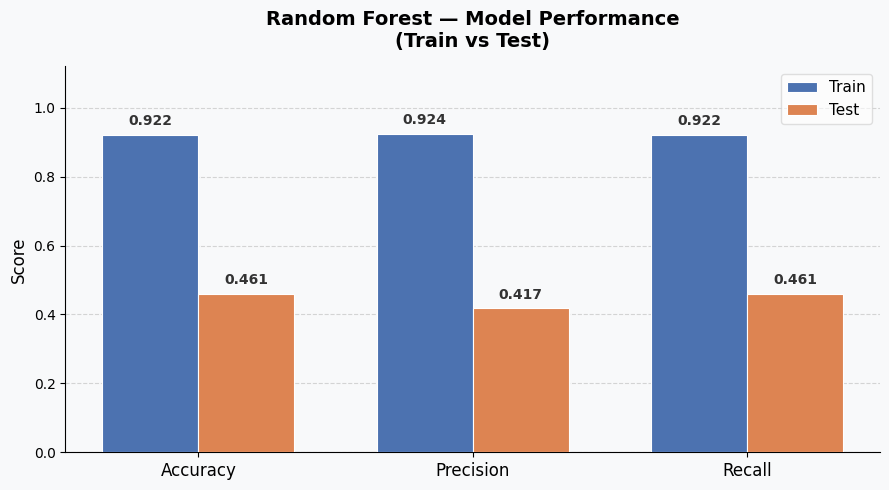

Plot saved → rf_performance_bar.png


In [47]:
metrics      = ["Accuracy", "Precision", "Recall"]
train_values = [train_metrics[m] for m in metrics]
test_values  = [test_metrics[m]  for m in metrics]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5), facecolor=PALETTE["bg"])
ax.set_facecolor(PALETTE["bg"])

bars_train = ax.bar(x - width/2, train_values, width,
                    label="Train", color=PALETTE["train"],
                    edgecolor="white", linewidth=0.8, zorder=3)
bars_test  = ax.bar(x + width/2, test_values,  width,
                    label="Test",  color=PALETTE["test"],
                    edgecolor="white", linewidth=0.8, zorder=3)

# Value labels on top of each bar
for bars in (bars_train, bars_test):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 5), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10,
                    fontweight="bold", color="#333333")

ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Random Forest — Model Performance\n(Train vs Test)",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(fontsize=11, framealpha=0.6)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("rf_performance_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → rf_performance_bar.png")

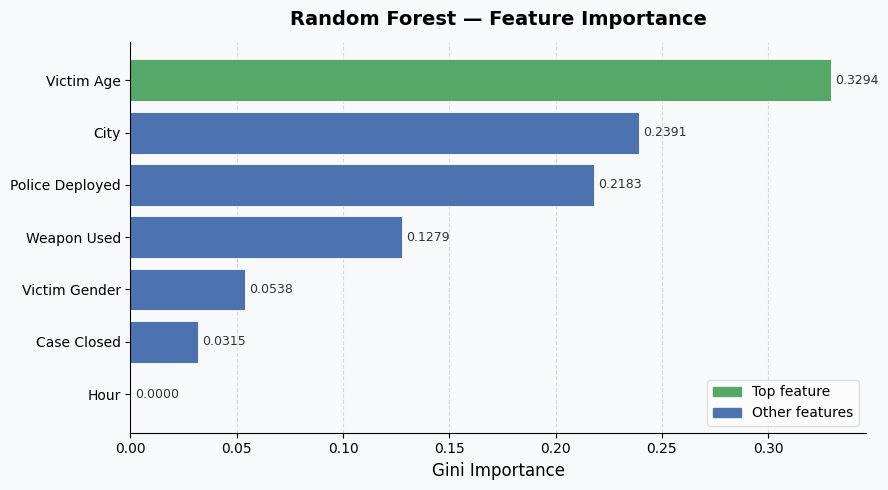

Plot saved → rf_feature_importance.png


In [48]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=PALETTE["bg"])
ax.set_facecolor(PALETTE["bg"])

colors = [PALETTE["accent"] if i == 0 else PALETTE["train"]
          for i in range(len(feat_df))]

bars = ax.barh(feat_df["Feature"], feat_df["Importance"],
               color=colors, edgecolor="white", linewidth=0.6)
ax.invert_yaxis()

for bar, val in zip(bars, feat_df["Importance"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, color="#333333")

ax.set_xlabel("Gini Importance", fontsize=12)
ax.set_title("Random Forest — Feature Importance", fontsize=14,
             fontweight="bold", pad=12)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

top_patch   = mpatches.Patch(color=PALETTE["accent"], label="Top feature")
other_patch = mpatches.Patch(color=PALETTE["train"],  label="Other features")
ax.legend(handles=[top_patch, other_patch], fontsize=10, framealpha=0.6)

plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → rf_feature_importance.png")

